<a href="https://colab.research.google.com/github/mnsbharadwaj/AI-NLP/blob/master/Transformer_components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ***Transformer Architecture***

## **INPUT EMBEDDING**

Input embedding converts each token (word, subword, etc.) into a fixed-length vector. These embeddings are learned during training.

Why We Need It:

Models can't process text directly.

We convert tokens into vectors in a continuous space.

Similar words have similar vectors.

These embeddings serve as the starting point for transformers. They are then enriched by positional encodings, which we’ll cover next.

In [ ]:
sentence = "The lion roared"
tokens = ["The", "lion", "roared"]
Each token becomes a vector like:

"The" → [0.21, -0.33, 0.41, ...]
"lion" → [0.91, 0.12, -0.45, ...]

🔎 Input Embeddings:
           dim0     dim1     dim2     dim3
The    0.374540 0.950714 0.731994 0.598658
lion   0.156019 0.155995 0.058084 0.866176
roared 0.601115 0.708073 0.020584 0.969910


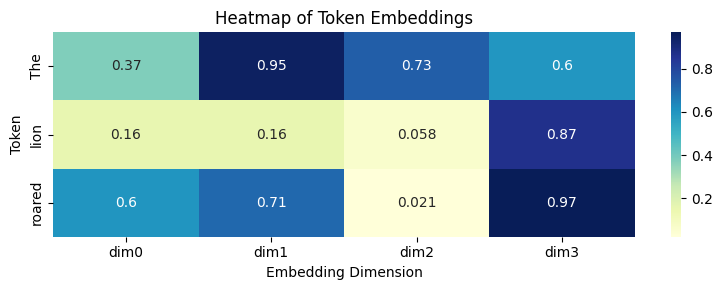

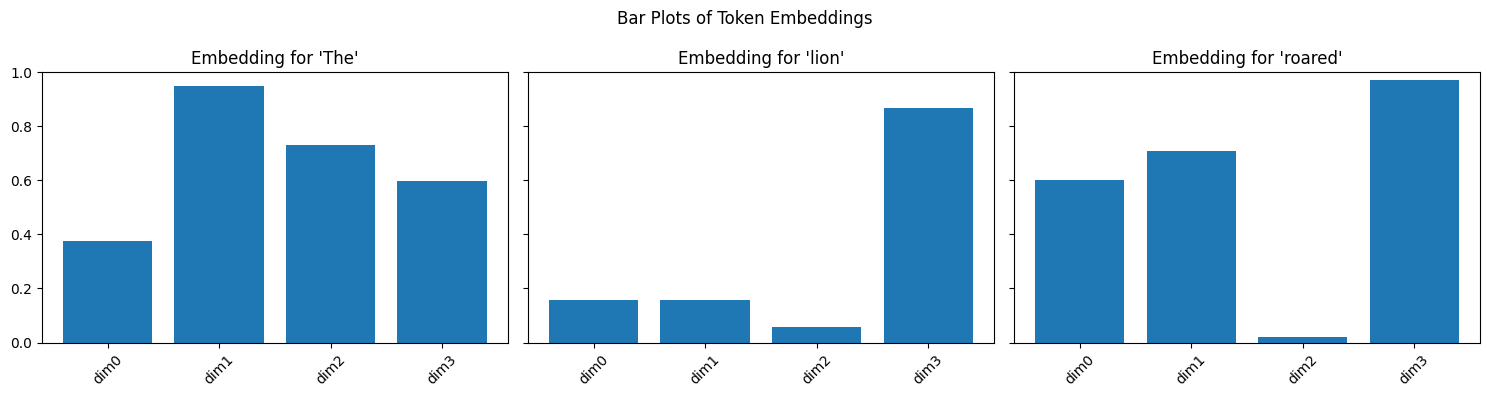

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define tokens and vocabulary
tokens = ["The", "lion", "roared"]
vocab = {"The": 0, "lion": 1, "roared": 2}
embedding_dim = 4  # small for illustration

# Step 2: Simulate an embedding matrix
np.random.seed(42)  # for consistent results
embedding_matrix = np.random.rand(len(vocab), embedding_dim)

# Step 3: Get embeddings for input tokens
input_indices = [vocab[token] for token in tokens]
input_embeddings = embedding_matrix[input_indices]

# Step 4: Create a DataFrame for plotting
df = pd.DataFrame(input_embeddings, index=tokens, columns=[f"dim{i}" for i in range(embedding_dim)])
print("🔎 Input Embeddings:")
print(df)

# Step 5: Plot Heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Heatmap of Token Embeddings")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

# Step 6: Plot Bar Chart for Each Token
fig, axes = plt.subplots(1, len(tokens), figsize=(15, 4), sharey=True)
for i, token in enumerate(tokens):
    axes[i].bar(df.columns, df.loc[token])
    axes[i].set_title(f"Embedding for '{token}'")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("Bar Plots of Token Embeddings")
plt.tight_layout()
plt.show()


## **POSTIONAL ENCODING**

In transformers, the model sees the input as a set of tokens (words or subwords).

However, it does not know the order of tokens (i.e., ["I", "am", "happy"] vs ["happy", "am", "I"]).

Positional Encoding adds unique information about token positions to the embeddings, allowing the model to learn sequence order.

For each position pos and dimension 𝑖:

 PE pos, 2i = sin(pos/(10000^((2i)/embedding_size)))

 PE pos,2i+1 = cos(pos/(10000^((2i)/embedding_size)))



You usually see graphs showing sinusoidal waves across dimensions.

Explaining PE for a single token "SAT" in a sentence "[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"

Each line represents how the positional encoding values change across the 64 dimensions for a specific token.

It clearly shows how token position affects the encoding.
 Both sine and cosine are used for every token — but in alternating dimensions of its positional encoding vector.

 For each postion say 3 and model dimension 6 the PE vector looks like this:
 | Dimension `i` | Formula Used   | Value           |

   0              $\sin\left(\frac{pos}{10000^{0/d}}\right)$  $\sin(3 / 1)



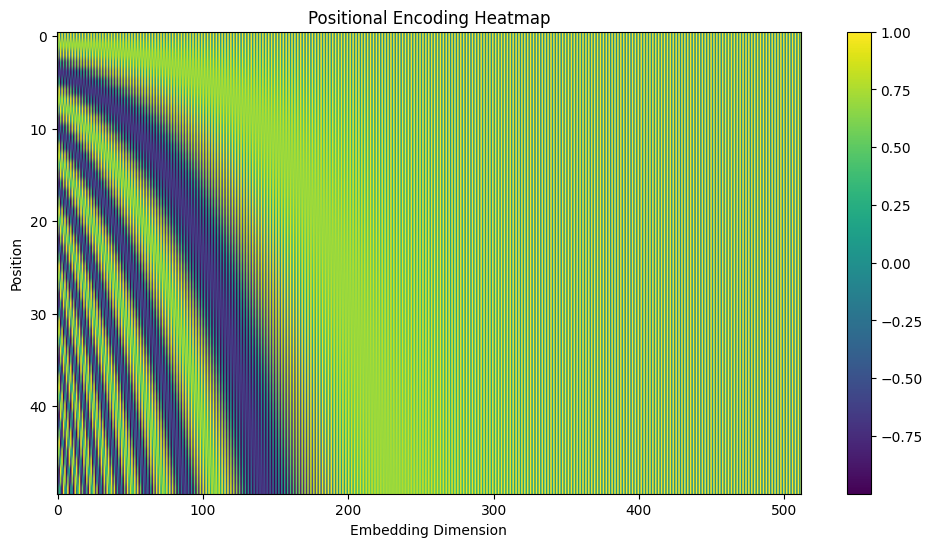

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]  # shape: (position, d_model)

    # apply sin to even indices; cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

pos_encoding = positional_encoding(np.arange(50)[:, np.newaxis], 512)

plt.figure(figsize=(12, 6))
plt.imshow(pos_encoding, aspect='auto', cmap='viridis')
plt.colorbar()
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Heatmap')
plt.show()


## The positional encoding heatmap graph (50 positions × 512 dimensions) gives visual insight into how transformers encode token positions using sine and cosine waves.

# Visualize Postional encoding of a single token in a  line graph

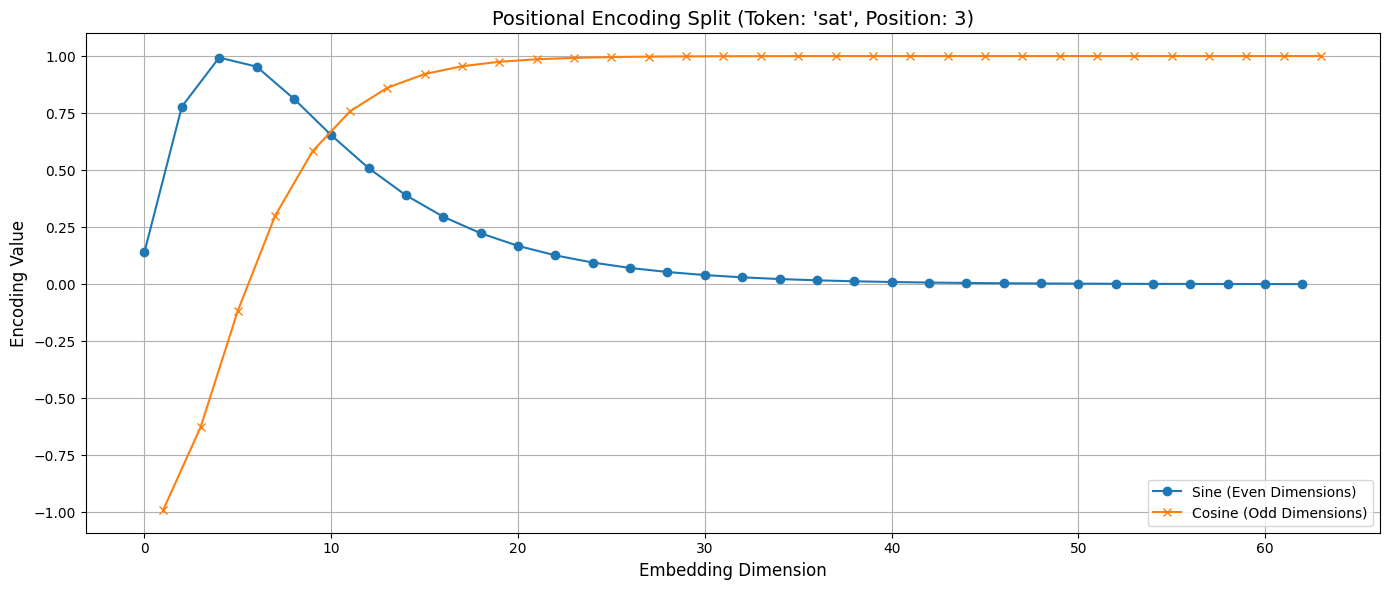

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the positional encoding function
def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

# Token setup
tokens = ["[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"]
pos_index = 3  # e.g., "sat"
d_model = 64

# Compute encoding
positions = np.arange(len(tokens))[:, np.newaxis]
pos_encoding = positional_encoding(positions, d_model)
token_encoding = pos_encoding[pos_index]
dimensions = np.arange(d_model)

# Plot sine and cosine parts
plt.figure(figsize=(14, 6))
plt.plot(dimensions[::2], token_encoding[::2], label="Sine (Even Dimensions)", marker='o')
plt.plot(dimensions[1::2], token_encoding[1::2], label="Cosine (Odd Dimensions)", marker='x')
plt.title(f"Positional Encoding Split (Token: '{tokens[pos_index]}', Position: {pos_index})", fontsize=14)
plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualize Postional encoding of a 2 tokens in a line graph

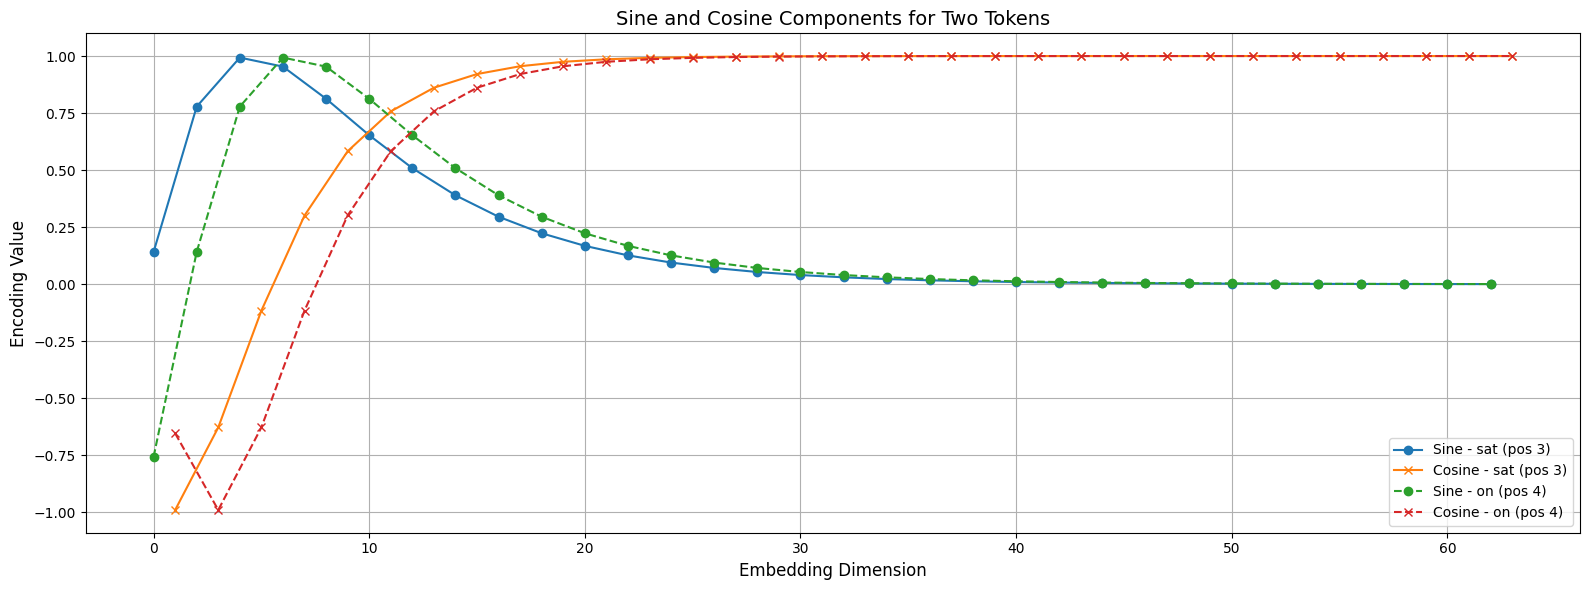

In [2]:
# Choose two positions
pos1 = 3  # "sat"
pos2 = 4  # "on"
encoding1 = pos_encoding[pos1]
encoding2 = pos_encoding[pos2]

# Plot sine/cosine comparison for two tokens
plt.figure(figsize=(16, 6))
plt.plot(dimensions[::2], encoding1[::2], label=f"Sine - {tokens[pos1]} (pos {pos1})", marker='o')
plt.plot(dimensions[1::2], encoding1[1::2], label=f"Cosine - {tokens[pos1]} (pos {pos1})", marker='x')
plt.plot(dimensions[::2], encoding2[::2], label=f"Sine - {tokens[pos2]} (pos {pos2})", linestyle='--', marker='o')
plt.plot(dimensions[1::2], encoding2[1::2], label=f"Cosine - {tokens[pos2]} (pos {pos2})", linestyle='--', marker='x')

plt.title("Sine and Cosine Components for Two Tokens", fontsize=14)
plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualize Postional encoding of all tokens in a line graph

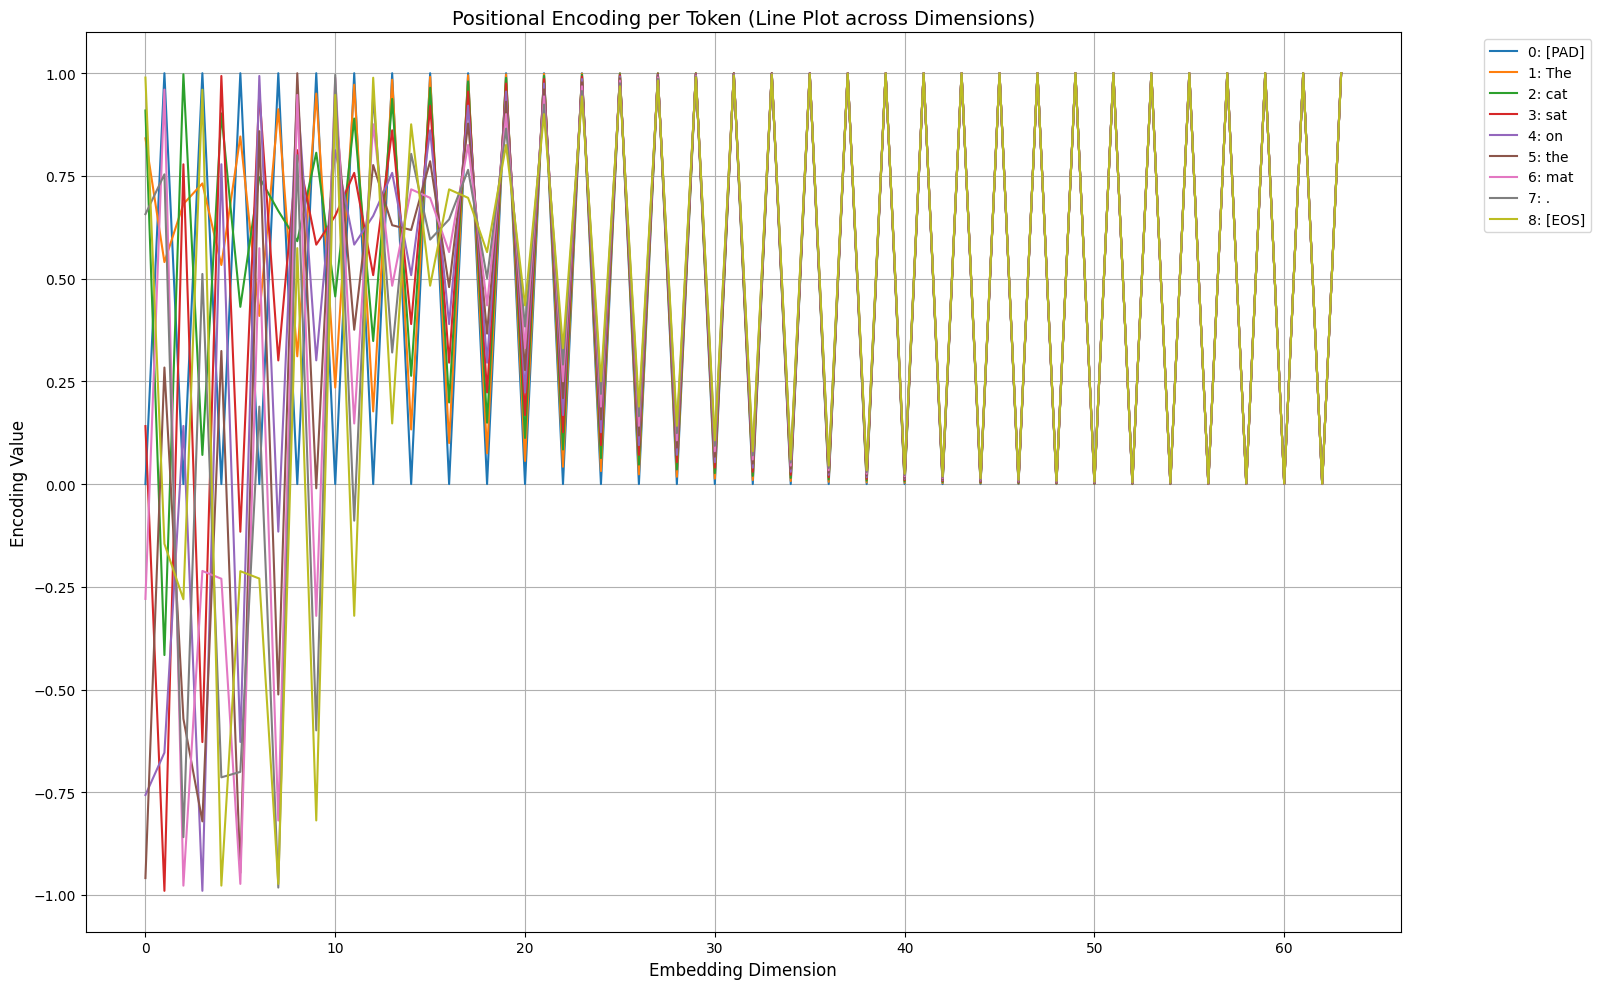

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the positional encoding function
def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]  # (position, d_model)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])   # sin for even indices
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])   # cos for odd indices
    return angle_rads

# Define example tokens and parameters
tokens = ["[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"]
max_len = len(tokens)
d_model = 64  # Smaller size for visualization

# Generate the positional encodings
positions = np.arange(max_len)[:, np.newaxis]
pos_encoding = positional_encoding(positions, d_model)

# Plot line graph showing positional encoding for each token
plt.figure(figsize=(16, 10))
for i, token in enumerate(tokens):
    plt.plot(pos_encoding[i], label=f"{i}: {token}")

plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.title("Positional Encoding per Token (Line Plot across Dimensions)", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
plt.grid(True)
plt.tight_layout()
plt.show()


## Exaplnation how a position and dimension are related.

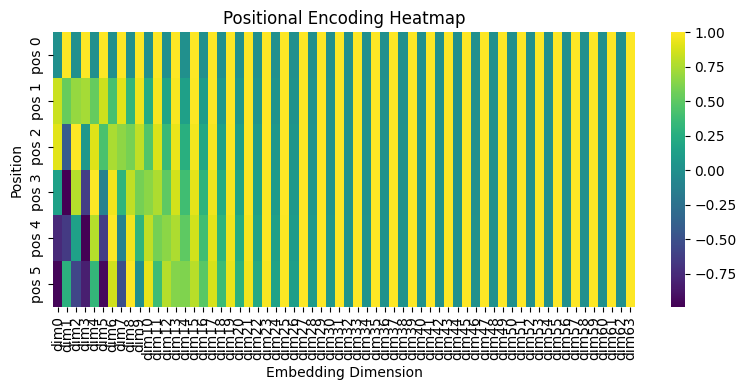

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Positional Encoding function
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]  # (max_len, 1)
    i = np.arange(d_model)[np.newaxis, :]    # (1, d_model)
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / d_model)
    angle_rads = pos * angle_rates

    # apply sin to even indices and cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

# Generate positional encodings
pos_encoding = positional_encoding(max_len=6, d_model=64)

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(pos_encoding, annot=False, cmap='viridis', xticklabels=[f"dim{i}" for i in range(64)],
            yticklabels=[f"pos {i}" for i in range(6)])
plt.title("Positional Encoding Heatmap")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.tight_layout()
plt.show()


## **Combined Encodings = Token Embeddings + Positional Encodings**

*Token Embeddings:*

  Random vectors representing token meanings (learned in training).

*Positional Encodings:*

  Sinusoidal vectors added to give each token a unique position identity.

*Combined Embeddings:*

  Element-wise sum of token + positional encodings.

  These are the actual inputs passed into the Transformer layers.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define sentence and vocabulary
tokens = ["The", "lion", "roared"]
vocab = {"The": 0, "lion": 1, "roared": 2}
embedding_dim = 8  # you can increase for more realistic visual

In [35]:
# Step 2: Simulate token embeddings
np.random.seed(42)
embedding_matrix = np.random.rand(len(vocab), embedding_dim)
input_indices = [vocab[token] for token in tokens]
token_embeddings = embedding_matrix[input_indices]  # shape: (3, 8)
print(token_embeddings)

[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
  0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985 0.83244264 0.21233911
  0.18182497 0.18340451]
 [0.30424224 0.52475643 0.43194502 0.29122914 0.61185289 0.13949386
  0.29214465 0.36636184]]


In [36]:
# Step 3: Generate positional encodings
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / d_model)
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

pos_encoding = positional_encoding(len(tokens), embedding_dim)
print(pos_encoding)

[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  9.98334166e-02  9.95004165e-01
   9.99983333e-03  9.99950000e-01  9.99999833e-04  9.99999500e-01]
 [ 9.09297427e-01 -4.16146837e-01  1.98669331e-01  9.80066578e-01
   1.99986667e-02  9.99800007e-01  1.99999867e-03  9.99998000e-01]]


In [37]:
# Step 4: Combine token embeddings and positional encodings
combined_embeddings = token_embeddings + pos_encoding
print(combined_embeddings)

[[0.37454012 1.95071431 0.73199394 1.59865848 0.15601864 1.15599452
  0.05808361 1.86617615]
 [1.442586   1.24837488 0.12041791 1.96491402 0.84244247 1.21228911
  0.18282497 1.18340401]
 [1.21353967 0.1086096  0.63061435 1.27129572 0.63185156 1.13929387
  0.29414465 1.36635984]]


In [38]:
# Step 5: Create DataFrames for visualization
token_df = pd.DataFrame(token_embeddings, index=tokens, columns=[f"dim{i}" for i in range(embedding_dim)])
posenc_df = pd.DataFrame(pos_encoding, index=tokens, columns=[f"dim{i}" for i in range(embedding_dim)])
combined_df = pd.DataFrame(combined_embeddings, index=tokens, columns=[f"dim{i}" for i in range(embedding_dim)])
print("Token DF")
print(token_df)
print("\nPositional Encoding DF")
print(posenc_df)
print("\nCombined DF")
print(combined_df)

Token DF
           dim0     dim1     dim2     dim3     dim4     dim5     dim6     dim7
The    0.374540 0.950714 0.731994 0.598658 0.156019 0.155995 0.058084 0.866176
lion   0.601115 0.708073 0.020584 0.969910 0.832443 0.212339 0.181825 0.183405
roared 0.304242 0.524756 0.431945 0.291229 0.611853 0.139494 0.292145 0.366362

Positional Encoding DF
           dim0      dim1     dim2     dim3     dim4     dim5     dim6  \
The    0.000000  1.000000 0.000000 1.000000 0.000000 1.000000 0.000000   
lion   0.841471  0.540302 0.099833 0.995004 0.010000 0.999950 0.001000   
roared 0.909297 -0.416147 0.198669 0.980067 0.019999 0.999800 0.002000   

           dim7  
The    1.000000  
lion   1.000000  
roared 0.999998  

Combined DF
           dim0     dim1     dim2     dim3     dim4     dim5     dim6     dim7
The    0.374540 1.950714 0.731994 1.598658 0.156019 1.155995 0.058084 1.866176
lion   1.442586 1.248375 0.120418 1.964914 0.842442 1.212289 0.182825 1.183404
roared 1.213540 0.108610 0.63061

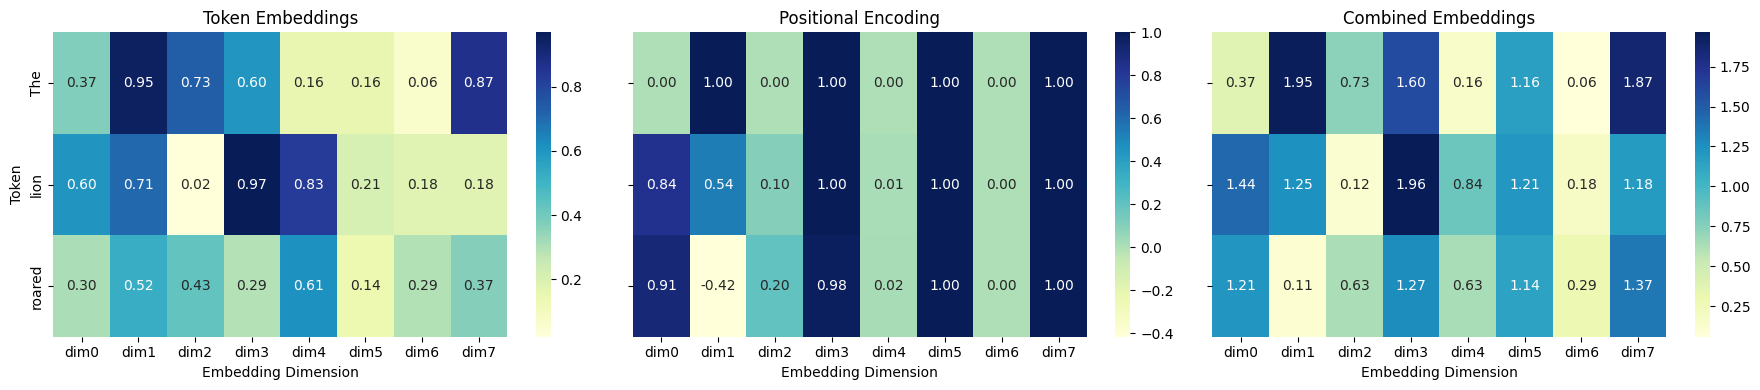

In [39]:
# Step 6: Plot heatmaps side-by-side
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(token_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=axs[0])
axs[0].set_title("Token Embeddings")
axs[0].set_ylabel("Token")

sns.heatmap(posenc_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=axs[1])
axs[1].set_title("Positional Encoding")
axs[1].set_yticklabels([])

sns.heatmap(combined_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=axs[2])
axs[2].set_title("Combined Embeddings")
axs[2].set_yticklabels([])

for ax in axs:
    ax.set_xlabel("Embedding Dimension")

plt.tight_layout()
plt.show()


Token Embedding	: Meaning of the word

Positional Encoding:	Location in the sequence

Combined Embedding:	Meaning + Location


## SELF ATTENTION

Self Attention:

Explanation of Self-Attention

Self-attention is a mechanism that allows a neural network to weigh the importance of different words in an input sequence to better understand the context of each word. Unlike traditional recurrent neural networks (RNNs) which process words sequentially, self-attention looks at the entire sequence simultaneously and computes a weighted sum of all input words for each output word. This weighted sum represents the contextually enriched representation of a word.

Here's how it works conceptually:

Queries, Keys, and Values: For each word in the input sequence, three vectors are created: a Query (Q), a Key (K), and a Value (V). These are typically derived from the original word embedding through linear transformations. Think of the Query as asking "what should I pay attention to?", the Key as a descriptor of what is available to be attended to, and the Value as the actual information to be aggregated.

Calculating Attention Scores: For each word's Query vector, it's compared with the Key vector of every other word in the sequence (including itself). This comparison is usually done using a dot product. The result is a score representing the similarity or relevance between the Query word and each Key word. A higher score means the Query word should pay more attention to that Key word.

Scaling and Softmax: The attention scores are typically scaled down (to prevent exploding gradients) and then passed through a softmax function. The softmax converts the scores into a probability distribution, where the probabilities sum up to 1. These probabilities represent the attention weights – how much attention the current word should pay to each other word in the sequence.

Weighted Sum of Values: The attention weights are then used to compute a weighted sum of the Value vectors of all words in the sequence. This weighted sum is the output representation for the current word, effectively incorporating information from the most relevant words in the sequence.

This process is repeated for every word in the input sequence, producing a new sequence of contextually richer representations.

Example:

Consider the sentence: "The animal didn't cross the street because it was too wide."

When processing the word "it", self-attention allows the network to understand that "it" refers to "the street". This is done by calculating attention scores between "it" (as the Query) and all other words (as Keys). The score between "it" and "the street" would be high, leading to a high attention weight for "the street" when computing the weighted sum of values for "it".

Now consider the sentence: "The animal didn't cross the street because it was too tired."

In this case, self-attention would likely assign a high attention weight to "the animal" when processing "it", correctly identifying that "it" refers to "the animal".

Diagram Description:

A typical diagram illustrating self-attention would show the following steps:

Input Embeddings: A sequence of word embeddings is shown as input.
Linear Transformations: Arrows would show each embedding being transformed into Query, Key, and Value vectors.
Dot Product: A matrix multiplication operation is depicted where the Query matrix is multiplied by the transposed Key matrix to obtain the attention scores.
Scaling and Softmax: The attention scores are shown being scaled and then passed through a softmax function to get attention weights.
Weighted Sum: The attention weights are shown multiplying the Value matrix, and the results are summed to produce the output context vectors.
The diagram would visually represent how each output vector is a weighted combination of the input Value vectors, with the weights determined by the attention scores. It would highlight the pairwise interactions between words in the sequence.



# Step-by-Step Breakdown of Self-Attention. Ex Sentence - "Lion looked at Zebra. It roared."

# 1. Tokenization
The sentence becomes tokens:["Lion", "looked", "at", "Zebra", ".", "It", "roared", "."].

Each of these will be represented by an embedding vector, say of dimension 4 or 8 (in real models, it's 512 or 768).

# 2. Create Q, K, V Vectors
Each token’s embedding is linearly projected into:

Q (Query vector): what this token is looking for

K (Key vector): what this token offers

V (Value vector): what actual information it carries

For example:

"roared" will get a Q vector

Every token (including "lion") will have a K and V.

# 3. Compute Attention Scores
Each token (say "roared") computes attention with all tokens:

score = 𝑄roared⋅𝐾token

Let’s say:

The dot product with "lion" is high (e.g., 3.2)

With "zebra", it's low (e.g., 0.4)

This shows "roared" is more interested in "lion", possibly because "lion" is the subject, and "roared" is a verb needing a subject.

# 4. Softmax Over Scores

**Token                    Raw Score                 Softmax**

Lion                        3.2                     0.78

looked                     1.5                      0.10

at                         0.7                      0.04

zebra                      0.4                      0.03

it                         1.2                       0.05


So "roared" gives 78% of its attention to "lion".

# 5.Weighted Sum of Value Vectors

Multiply each V vector by its attention weight and sum them up.

This gives a new vector for "roared" that is:

Mostly influenced by "lion"

Slightly by "looked", "It", etc.

# 6. Result: Context-Aware Embedding
Now the output for "roared" reflects:

That it’s likely "lion" who roared (not zebra!)

So when the model generates or classifies, it understands this dependency

In [4]:
pip install transformers torch seaborn



SyntaxError: invalid syntax (ipython-input-4-2488520158.py, line 1)

It looks like the `pip install` command caused a `SyntaxError` because it was run directly in a Python cell. You need to add an exclamation mark `!` before shell commands in Colab code cells.

I'll generate a new cell with the corrected command to install the necessary libraries.

In [5]:
!pip install transformers torch seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink


🔎 Attention from 'roared':
    Token  Attention Weight
0   [CLS]          0.013405
1    lion          0.002927
2  looked          0.000955
3      at          0.000847
4   zebra          0.002336
5       .          0.001115
6      it          0.002443
7  roared          0.001791
8       .          0.000768
9   [SEP]          0.973412


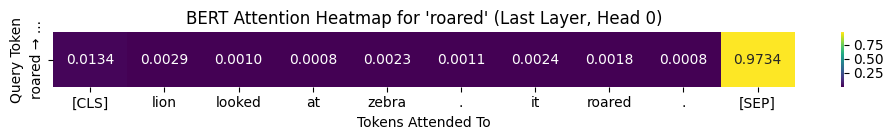

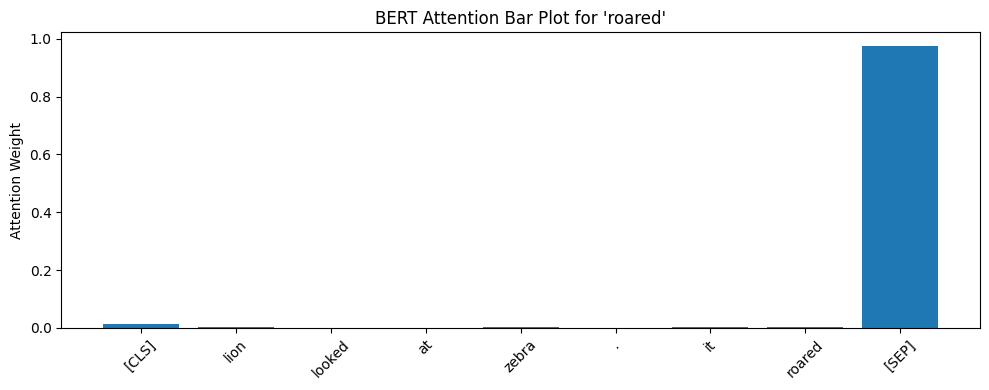

In [12]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

# Input sentence
sentence = "Lion looked at Zebra. It roared."
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Run BERT with attention
with torch.no_grad():
    outputs = model(**inputs)

# Get attention from last layer, head 0
attentions = outputs.attentions  # shape: (12 layers, batch, 12 heads, seq_len, seq_len)
attention_matrix = attentions[-1][0, 0]  # last layer, first head: (seq_len, seq_len)

# Find index of the token "roared"
try:
    target_index = tokens.index("roared")
except ValueError:
    print("Token 'roared' not found. Check how BERT tokenized the sentence:")
    print(tokens)
    exit()

# Get attention vector from "roared" to all tokens
attention_vector = attention_matrix[target_index].numpy()

# Normalize (softmax) manually, just for clarity (BERT already softmaxes internally)
attention_softmax = attention_vector / attention_vector.sum()

# Print table
df = pd.DataFrame({
    "Token": tokens,
    "Attention Weight": attention_softmax
})
pd.set_option('display.float_format', '{:.6f}'.format)
print("\n🔎 Attention from 'roared':")
print(df)

# Plot heatmap with more precision
plt.figure(figsize=(10, 1.5))
sns.heatmap([attention_softmax], annot=True, fmt=".4f", cmap="viridis",
            xticklabels=tokens, yticklabels=["roared → ..."])
plt.title("BERT Attention Heatmap for 'roared' (Last Layer, Head 0)")
plt.xlabel("Tokens Attended To")
plt.ylabel("Query Token")
plt.tight_layout()
plt.show()

# Plot bar chart (easier to read)
plt.figure(figsize=(10, 4))
plt.bar(tokens, attention_softmax)
plt.xticks(rotation=45)
plt.ylabel("Attention Weight")
plt.title("BERT Attention Bar Plot for 'roared'")
plt.tight_layout()
plt.show()


## SIMULATION OF SELF ATTENTION

Step 1: Tokens and Empty Embeddings

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Tokens and Dummy Embeddings
tokens = ["Lion", "looked", "at", "Zebra", ".", "It", "roared", "."]
embedding_dim = 4
np.random.seed(1)  # For reproducibility

# Simulate embeddings (in real models, these come from an embedding layer)
embeddings = np.random.rand(len(tokens), embedding_dim)  # shape: (8, 4)
print(embeddings)

[[4.17022005e-01 7.20324493e-01 1.14374817e-04 3.02332573e-01]
 [1.46755891e-01 9.23385948e-02 1.86260211e-01 3.45560727e-01]
 [3.96767474e-01 5.38816734e-01 4.19194514e-01 6.85219500e-01]
 [2.04452250e-01 8.78117436e-01 2.73875932e-02 6.70467510e-01]
 [4.17304802e-01 5.58689828e-01 1.40386939e-01 1.98101489e-01]
 [8.00744569e-01 9.68261576e-01 3.13424178e-01 6.92322616e-01]
 [8.76389152e-01 8.94606664e-01 8.50442114e-02 3.90547832e-02]
 [1.69830420e-01 8.78142503e-01 9.83468338e-02 4.21107625e-01]]


Step 2: Define Random Linear Projection Matrices for Q, K, V

In [17]:
W_q = np.random.rand(embedding_dim, embedding_dim)  # (4, 4)
W_k = np.random.rand(embedding_dim, embedding_dim)
W_v = np.random.rand(embedding_dim, embedding_dim)

print("Q" + str(W_q))
print("K" + str(W_k))
print("V" + str(W_v))

Q[[0.66923289 0.26491956 0.06633483 0.3700842 ]
 [0.62971751 0.21017401 0.75275555 0.06653648]
 [0.2603151  0.80475456 0.19343428 0.63946088]
 [0.52467031 0.92480797 0.26329677 0.06596109]]
K[[0.73506596 0.77217803 0.90781585 0.93197207]
 [0.01395157 0.23436209 0.61677836 0.94901632]
 [0.95017612 0.55665319 0.91560635 0.64156621]
 [0.39000771 0.48599067 0.60431048 0.54954792]]
V[[0.92618143 0.91873344 0.39487561 0.96326253]
 [0.17395567 0.12632952 0.13507916 0.50566217]
 [0.02152481 0.94797021 0.82711547 0.01501898]
 [0.17619626 0.33206357 0.13099684 0.80949069]]


 Step 3: Compute Q, K, V matrices

In [19]:
Q = embeddings @ W_q  # shape: (8, 4)
K = embeddings @ W_k
V = embeddings @ W_v
print("Q" + str(Q))
print("K" + str(K))
print("V" + str(V))

Q[[0.89134048 0.54156239 0.64951666 0.22227644]
 [0.3861529  0.52775675 0.20625755 0.2023556 ]
 [1.07346916 1.18940189 0.69341947 0.49594466]
 [1.04869589 0.88081485 0.85639971 0.19582945]
 [0.77157368 0.52415715 0.52755385 0.29445011]
 [1.59044604 1.30813133 1.02489483 0.60685649]
 [1.1924871  0.52475359 0.75828873 0.4408203 ]
 [0.91318164 0.69814288 0.80219225 0.21194574]]
K[[0.43460905 0.63782646 1.00566721 1.23847218]
 [0.42091488 0.40658397 0.56954677 0.53380366]
 [0.96471711 0.99900959 1.49042479 1.52662407]
 [0.45004755 0.70475731 1.15745562 1.40991655]
 [0.52519458 0.62759163 0.97167769 1.11805596]
 [1.16992818 1.35617206 2.02948238 2.24671443]
 [0.75272365 0.95271072 1.44884223 1.7417905 ]
 [0.39477007 0.59634208 1.04032078 1.2861636 ]]
V[[0.56481489 0.57463236 0.30167186 1.01067964]
 [0.21688112 0.4378119  0.26974941 0.47058221]
 [0.59096508 1.05751235 0.66594057 1.21562516]
 [0.46083676 0.54736973 0.3098304  1.1841205 ]
 [0.52161376 0.65283582 0.38231772 0.84695217]
 [1.0388

Step 4: Choose Token Roared as the query

In [20]:
query_index = 6
q = Q[query_index]  # shape: (4,)
print(q)

[1.1924871  0.52475359 0.75828873 0.4408203 ]


Step 5: Compute raw attention scores with all tokens

In [21]:
scores = q @ K.T  # shape: (8,)
print("Raw attention scores:", np.round(scores, 2))


Raw attention scores: [2.16 1.38 3.48 2.41 2.19 4.64 3.26 2.14]


Step 6: Scale the scores by sqrt(d_k)

In [22]:
d_k = embedding_dim
scaled_scores = scores / np.sqrt(d_k)
print(scaled_scores)

[1.0807486  0.69124218 1.73889289 1.2028526  1.09264636 2.31805568
 1.63200448 1.0697607 ]


Step 7: Apply Softmax to get attention weights

In [23]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()
attention_weights = softmax(scaled_scores)
print("Softmax attention weights:", np.round(attention_weights, 2))


Softmax attention weights: [0.08 0.06 0.16 0.09 0.08 0.29 0.15 0.08]


Step 8: Weighted sum of value vectors (context vector for "roared")

In [24]:
context_vector = attention_weights @ V  # shape: (4,)
print("Context vector for 'roared':", np.round(context_vector, 2))
attention_table = {
    "Token": tokens,
    "Score": np.round(scores, 2),
    "Weight (softmax)": np.round(attention_weights, 2)
}

attention_df = pd.DataFrame(attention_table)
print("\n--- Self-Attention Weights for 'roared' ---")
print(attention_df)


Context vector for 'roared': [0.72 0.94 0.55 1.29]

--- Self-Attention Weights for 'roared' ---
    Token    Score  Weight (softmax)
0    Lion 2.160000          0.080000
1  looked 1.380000          0.060000
2      at 3.480000          0.160000
3   Zebra 2.410000          0.090000
4       . 2.190000          0.080000
5      It 4.640000          0.290000
6  roared 3.260000          0.150000
7       . 2.140000          0.080000


Each row adds up to 1 (softmax).

You can see which tokens are most "influential" to others in this toy model.

This simulation uses random weights — so relationships like "roared" attending to "Lion" may not match human intuition.

Step 9: PLot Heatmap for roared

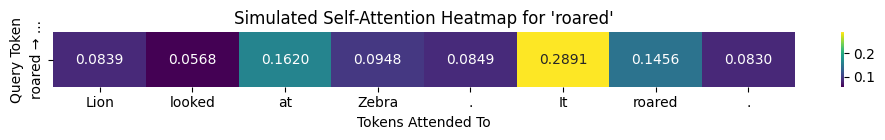

In [25]:
plt.figure(figsize=(10, 1.5))
sns.heatmap([attention_weights], annot=True, fmt=".4f", cmap="viridis",
            xticklabels=tokens, yticklabels=["roared → ..."])
plt.title("Simulated Self-Attention Heatmap for 'roared'")
plt.xlabel("Tokens Attended To")
plt.ylabel("Query Token")
plt.tight_layout()
plt.show()

## **Add & Layer Normalization**

Every sub-layer (like self-attention or FFN) is wrapped as:
LayerNorm(x + Sublayer(x))

x is the input

Sublayer(x) is the output of attention or FFN

+ is the residual connection

LayerNorm normalizes the result

# 1. Residual (Skip) Connection
Adds the input to the output of the layer.

Helps gradient flow in deep networks.

Makes training stable and faster.

# 2. Layer Normalization
Normalizes values across dimensions for each token independently.

Keeps the scale of activations consistent.